In [1]:
!kaggle datasets download -d carlolepelaars/camvid

Dataset URL: https://www.kaggle.com/datasets/carlolepelaars/camvid
License(s): CC-BY-NC-SA-4.0
100% 575M/575M [00:34<00:00, 17.5MB/s]



In [2]:
!unzip camvid.zip

Archive:  camvid.zip
  inflating: CamVid/class_dict.csv   
  inflating: CamVid/test/0001TP_006690.png  
  inflating: CamVid/test/0001TP_006720.png  
  inflating: CamVid/test/0001TP_006750.png  
  inflating: CamVid/test/0001TP_006780.png  
  inflating: CamVid/test/0001TP_006810.png  
  inflating: CamVid/test/0001TP_006840.png  
  inflating: CamVid/test/0001TP_006870.png  
  inflating: CamVid/test/0001TP_006900.png  
  inflating: CamVid/test/0001TP_006930.png  
  inflating: CamVid/test/0001TP_006960.png  
  inflating: CamVid/test/0001TP_006990.png  
  inflating: CamVid/test/0001TP_007020.png  
  inflating: CamVid/test/0001TP_007050.png  
  inflating: CamVid/test/0001TP_007080.png  
  inflating: CamVid/test/0001TP_007110.png  
  inflating: CamVid/test/0001TP_007140.png  
  inflating: CamVid/test/0001TP_007170.png  
  inflating: CamVid/test/0001TP_007200.png  
  inflating: CamVid/test/0001TP_007230.png  
  inflating: CamVid/test/0001TP_007260.png  
  inflating: CamVid/test/0001TP_007290.pn

In [1]:
import os

for root, dirs, files in os.walk("/content"):
    if len(files) > 0:
        print(root)
        print(files[:5])
        print("-"*50)

/content
['camvid.zip']
--------------------------------------------------
/content/.config
['config_sentinel', 'gce', '.last_update_check.json', 'default_configs.db', '.last_survey_prompt.yaml']
--------------------------------------------------
/content/.config/configurations
['config_default']
--------------------------------------------------
/content/.config/logs/2026.09.30
['13.28.20.944029.log', '13.27.22.328650.log', '13.28.20.222644.log', '13.28.06.747575.log', '13.28.09.380692.log']
--------------------------------------------------
/content/CamVid
['class_dict.csv']
--------------------------------------------------
/content/CamVid/test_labels
['0016E5_05700_L.png', '0016E5_06540_L.png', '0001TP_009090_L.png', '0001TP_007020_L.png', '0001TP_006960_L.png']
--------------------------------------------------
/content/CamVid/val
['0006R0_f03420.png', 'Seq05VD_f02970.png', '0016E5_06300.png', 'Seq05VD_f03870.png', '0016E5_06330.png']
----------------------------------------------

In [2]:
import glob

image_paths = sorted(
    glob.glob(
        "/content/CamVid/train/*.png",
        recursive=True
    )
)

mask_paths = sorted(
    glob.glob(
        "/content/CamVid/train_labels/*.png",
        recursive=True
    )
)

print(len(image_paths))
print(len(mask_paths))

369
369


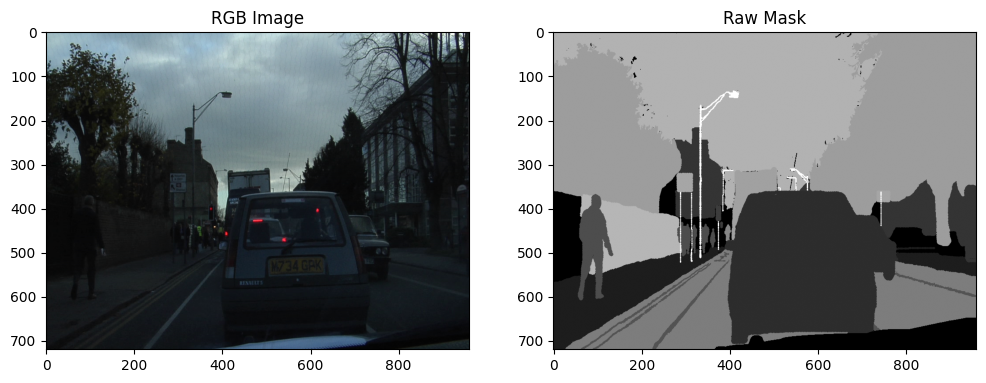

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.cvtColor(
    cv2.imread(image_paths[0]),
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(
    mask_paths[0],
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Raw Mask")

plt.show()

In [4]:
import numpy as np

print(np.unique(mask))

[  0  21  33  38  44  56  60  90  97 113 116 120 128 131 184]


In [5]:
unique_ids = [0,21,33,38,44,56,60,90,97,113,116,120,128,131,184]

id_map = {old:new for new, old in enumerate(unique_ids)}

print(id_map)

{0: 0, 21: 1, 33: 2, 38: 3, 44: 4, 56: 5, 60: 6, 90: 7, 97: 8, 113: 9, 116: 10, 120: 11, 128: 12, 131: 13, 184: 14}


In [6]:
import numpy as np

def encode_mask(mask):

    encoded = np.ones(mask.shape, dtype=np.uint8) * 255

    for k, v in id_map.items():
        encoded[mask == k] = v

    return encoded

In [7]:
encoded_mask = encode_mask(mask)

print(np.unique(encoded_mask))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [8]:
from torch.utils.data import Dataset
import torch
import numpy as np
import cv2



class CamVidDataset(Dataset):

    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            self.mask_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(
            mask,
            (256,256),
            interpolation=cv2.INTER_NEAREST
        )

        mask = encode_mask(mask) # Apply encoding

        image = image.astype(np.float32) / 255.0

        image = torch.tensor(image).permute(2,0,1)
        mask = torch.tensor(mask).long()

        return image, mask

In [44]:
import glob

# Define the train and validation image and mask paths
train = sorted(glob.glob('/content/CamVid/train/*.png'))
train_masks = sorted(glob.glob('/content/CamVid/train_labels/*.png'))

val_imgs = sorted(glob.glob('/content/CamVid/val/*.png'))
val_masks = sorted(glob.glob('/content/CamVid/val_labels/*.png'))
test_imgs = sorted(glob.glob('/content/CamVid/test/*.png'))
test_masks = sorted(glob.glob('/content/CamVid/test_labels/*.png'))

# Initialize the datasets
train_dataset = CamVidDataset(
    train,
    train_masks
)

val_dataset = CamVidDataset(
    val_imgs,
    val_masks
)

test_dataset = CamVidDataset(
    test_imgs,
    test_masks
)

In [45]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [11]:
images, masks = next(iter(train_loader))
print(images.shape)
print(masks.shape)

torch.Size([8, 3, 256, 256])
torch.Size([8, 256, 256])


In [12]:
import torch
import torch.nn as nn

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

In [14]:
class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=15):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        # Output Layer
        self.final_conv = nn.Conv2d(
            32,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    in_channels=3,
    num_classes=15
).to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding

In [16]:
x = torch.randn(2, 3, 256, 256).to(device)

y = model(x)

print(y.shape)

torch.Size([2, 15, 256, 256])


In [17]:
criterion = nn.CrossEntropyLoss(
    ignore_index=255
)

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [19]:
num_epochs = 50

for epoch in range(num_epochs):

    # ========================
    # TRAINING
    # ========================
    model.train()

    train_loss = 0
    train_correct = 0
    train_pixels = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.long().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_correct += (preds == masks).sum().item()
        train_pixels += masks.numel()

    train_acc = train_correct / train_pixels

    # ========================
    # VALIDATION
    # ========================

    model.eval()

    val_loss = 0
    val_correct = 0
    val_pixels = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.long().to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == masks).sum().item()
            val_pixels += masks.numel()

    val_acc = val_correct / val_pixels

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/50] | Train Loss: 2.1530 | Train Acc: 0.4727 | Val Loss: 1.8397 | Val Acc: 0.5777
Epoch [2/50] | Train Loss: 1.7049 | Train Acc: 0.6163 | Val Loss: 1.5138 | Val Acc: 0.6694
Epoch [3/50] | Train Loss: 1.4973 | Train Acc: 0.6784 | Val Loss: 1.4149 | Val Acc: 0.6953
Epoch [4/50] | Train Loss: 1.3644 | Train Acc: 0.7351 | Val Loss: 1.3043 | Val Acc: 0.7533
Epoch [5/50] | Train Loss: 1.2615 | Train Acc: 0.7674 | Val Loss: 1.2296 | Val Acc: 0.7675
Epoch [6/50] | Train Loss: 1.1835 | Train Acc: 0.7802 | Val Loss: 1.1417 | Val Acc: 0.7791
Epoch [7/50] | Train Loss: 1.1009 | Train Acc: 0.7890 | Val Loss: 1.0906 | Val Acc: 0.7725
Epoch [8/50] | Train Loss: 1.0450 | Train Acc: 0.7912 | Val Loss: 1.0822 | Val Acc: 0.7701
Epoch [9/50] | Train Loss: 0.9779 | Train Acc: 0.7950 | Val Loss: 0.9516 | Val Acc: 0.7931
Epoch [10/50] | Train Loss: 0.9248 | Train Acc: 0.7997 | Val Loss: 0.9256 | Val Acc: 0.7901
Epoch [11/50] | Train Loss: 0.8920 | Train Acc: 0.8016 | Val Loss: 0.9119 | Val Acc: 0.78

In [20]:
best_loss = float("inf")

if val_loss < best_loss:

    best_loss = val_loss

    torch.save(
        model.state_dict(),
        "best_unet.pth"
    )

In [21]:
model.eval()

image, mask = val_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(device)
    )

pred = torch.argmax(pred, dim=1)
pred = pred.squeeze().cpu().numpy()

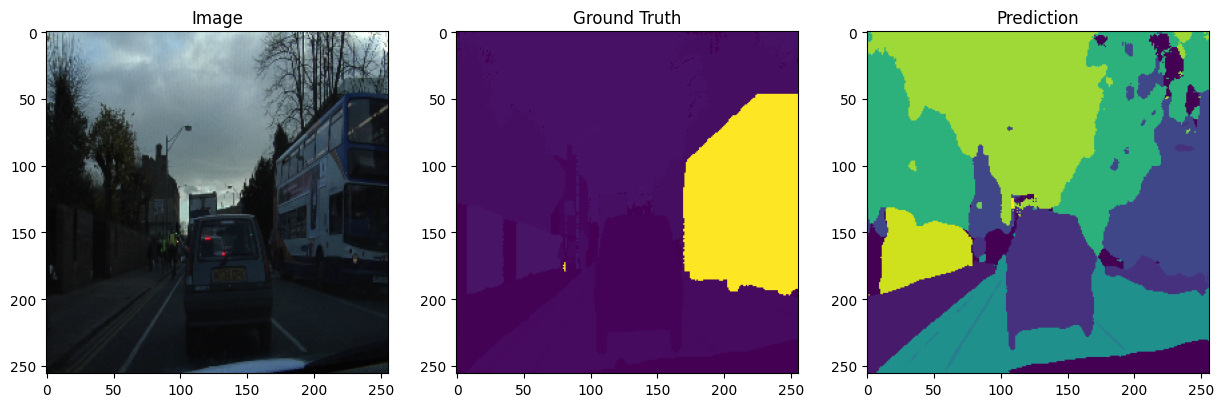

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(image.permute(1,2,0))

plt.title("Image")

plt.subplot(132)
plt.imshow(mask)

plt.title("Ground Truth")

plt.subplot(133)
plt.imshow(pred)

plt.title("Prediction")

plt.show()

In [23]:
preds = torch.argmax(outputs, dim=1)

acc = (preds == masks).float().mean()

print(acc.item())

0.8725357055664062


In [24]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

outputs = model(images.to(device))

print(outputs.shape)

torch.Size([8, 3, 256, 256])
torch.Size([8, 256, 256])
torch.Size([8, 15, 256, 256])


In [26]:
torch.save(
    model.state_dict(),
    "/content/unet_camvid.pth"
)

In [28]:
checkpoint = torch.load("best_unet.pth")

model.load_state_dict(checkpoint)
model.eval()

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding

In [29]:
def iou_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()

In [31]:
num_classes = 15
iou_per_class = torch.zeros(num_classes).to(device)
class_counts = torch.zeros(num_classes).to(device)

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)  # shape: [batch, height, width]

        outputs = model(images)   # shape: [batch, 15, height, width]
        preds = torch.argmax(outputs, dim=1) # shape: [batch, height, width]

        for cls in range(num_classes):
            pred_cls = (preds == cls)
            target_cls = (masks == cls)

            # If the class is not present in target or prediction, we can skip it to avoid skewing the average
            if target_cls.sum() == 0 and pred_cls.sum() == 0:
                continue

            intersection = (pred_cls & target_cls).sum().float()
            union = (pred_cls | target_cls).sum().float()

            iou_per_class[cls] += intersection / (union + 1e-6)
            class_counts[cls] += 1

# Average IoU over batches for each class, then average across all active classes
mean_iou_per_class = iou_per_class / (class_counts + 1e-6)
mean_iou = mean_iou_per_class[class_counts > 0].mean().item()

print("Mean IoU:", mean_iou)

Mean IoU: 0.38197436928749084


In [33]:
model = UNet().to(device)

checkpoint = torch.load("best_unet.pth")

model.load_state_dict(
    checkpoint
)

model.eval()

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding

In [36]:
!pip install torch torchvision opencv-python


In [37]:
import cv2
import torch
import numpy as np

model.eval()

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    img = cv2.resize(frame, (256, 256))

    img = img.astype(np.float32) / 255.0

    img = torch.tensor(
        img.transpose(2,0,1)
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(img)

        pred = torch.argmax(output, dim=1)

        mask = pred.squeeze().cpu().numpy().astype(np.uint8)

    colored_mask = cv2.applyColorMap(
        (mask * 15).astype(np.uint8),
        cv2.COLORMAP_JET
    )

    cv2.imshow("Original", frame)
    cv2.imshow("Segmentation", colored_mask)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [40]:
import cv2

cap = cv2.VideoCapture(0)

print(cap.isOpened())

False


In [38]:
!pip freeze > requirements.txt

In [41]:
!cat requirements.txt


absl-py==1.4.0
accelerate==1.15.0
access==1.1.10.post3
affine==3.0.1
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.1
altair==5.5.0
annotated-doc==0.0.5
annotated-types==0.8.0
antlr4-python3-runtime==4.9.3
anyio==4.15.1
anywidget==0.9.21
apsw==3.53.4.0
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.9.14.0.56.43
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioop-lts==0.2.2
audioread==3.1.0
Authlib==1.8.0
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.49.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.3.0
blosc2==4.13.1
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.7.22
cffi==2.1.1
ch

In [42]:
import numpy as np

def mean_dice_score(preds, masks, num_classes=15):
    """
    preds: Tensor (B,H,W)
    masks: Tensor (B,H,W)
    """

    preds = preds.cpu().numpy()
    masks = masks.cpu().numpy()

    dice_scores = []

    for cls in range(num_classes):

        pred_cls = (preds == cls)
        mask_cls = (masks == cls)

        intersection = np.logical_and(
            pred_cls,
            mask_cls
        ).sum()

        dice = (
            2 * intersection + 1e-6
        ) / (
            pred_cls.sum() +
            mask_cls.sum() +
            1e-6
        )

        dice_scores.append(dice)

    return np.mean(dice_scores)

In [46]:
model.eval()

total_dice = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        total_dice += mean_dice_score(
            preds,
            masks,
            num_classes=15
        )

final_mean_dice = total_dice / len(test_loader)

print(f"Mean Dice Score: {final_mean_dice:.4f}")

Mean Dice Score: 0.4633
